### A Dataset class

It must inherit from PyTorch's Dataset class, and it must have exactly these method names - __init__, __len__, __getitem__ 

because PyTorch looks for these specific names.

In [2]:
folder_path = ("/Users/asim/Desktop/CNN/IMG_5369.jpg")

In [3]:
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, folder_path):
        self.img_paths = folder_path

    def __len__(self):
        pass

    def __getitem__(self, idx):
        pass

In [1]:
import torch
import torch.nn as nn

conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
pool = nn.MaxPool2d(kernel_size=2, stride=2)

x = torch.randn(1, 3, 64, 64)  # (batch, channels, H, W)
print("input:", x.shape)

x = conv(x)
print("after conv:", x.shape)

x = pool(x)
print("after pool:", x.shape)

input: torch.Size([1, 3, 64, 64])
after conv: torch.Size([1, 16, 64, 64])
after pool: torch.Size([1, 16, 32, 32])


In [2]:
import cv2

img = cv2.imread("sample.jpg")  # cv2 loads as BGR
print("raw (BGR):", img[0, 0])  # e.g. [B, G, R] values

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print("converted (RGB):", img_rgb[0, 0])

[ WARN:0@0.018] global loadsave.cpp:278 findDecoder imread_('sample.jpg'): can't open/read file: check file path/integrity


TypeError: 'NoneType' object is not subscriptable

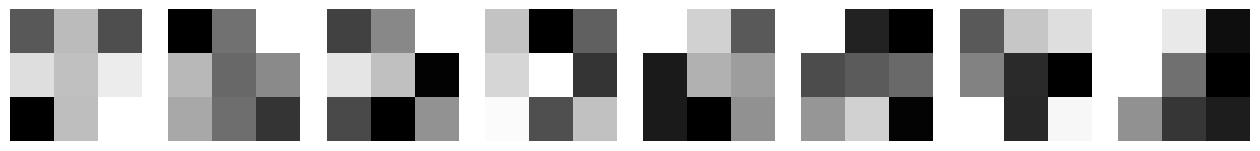

In [3]:
import torch.nn as nn
import matplotlib.pyplot as plt

conv = nn.Conv2d(3, 8, kernel_size=3)
weights = conv.weight.data  # shape: (8, 3, 3, 3)

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(weights[i, 0], cmap="gray")  # just the R channel of each filter
    ax.axis("off")
plt.show()

In [1]:
import torch

img = torch.randn(3, 224, 224)  # single image, no batch dim
print("original:", img.shape)

batched = img.unsqueeze(0)  # add batch dim for model input
print("batched:", batched.shape)

back = batched.squeeze(0)  # remove it again
print("squeezed:", back.shape)

original: torch.Size([3, 224, 224])
batched: torch.Size([1, 3, 224, 224])
squeezed: torch.Size([3, 224, 224])


In [2]:
import torch
from torchvision import transforms

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

transform = transforms.Normalize(mean=mean, std=std)

x = torch.rand(3, 64, 64)  # values in [0,1]
x_norm = transform(x)
print("before:", x.min().item(), x.max().item())
print("after:", x_norm.min().item(), x_norm.max().item())

before: 0.00021952390670776367 0.999957263469696
after: -2.116875410079956 2.638488531112671


In [3]:
import torch

preds = torch.tensor([1, 2, 2, 0, 1])
labels = torch.tensor([1, 2, 0, 0, 1])

num_classes = 3
conf_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)

for p, l in zip(preds, labels):
    conf_matrix[l, p] += 1

print(conf_matrix)

tensor([[1, 0, 1],
        [0, 2, 0],
        [0, 0, 1]])


In [4]:
import torch
import torch.nn as nn

x = torch.randn(1, 3, 128, 128)

stage1 = nn.Conv2d(3, 16, 3, stride=2, padding=1)   # 128 -> 64
stage2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)  # 64 -> 32
stage3 = nn.Conv2d(32, 64, 3, stride=2, padding=1)  # 32 -> 16

out1 = stage1(x)
out2 = stage2(out1)
out3 = stage3(out2)

for name, t in [("stage1", out1), ("stage2", out2), ("stage3", out3)]:
    print(f"{name}: spatial={t.shape[-2:]}, channels={t.shape[1]}")

stage1: spatial=torch.Size([64, 64]), channels=16
stage2: spatial=torch.Size([32, 32]), channels=32
stage3: spatial=torch.Size([16, 16]), channels=64


In [5]:
import torch
import torch.nn as nn

model = nn.Linear(784, 10)  # placeholder — swap for your real net
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# for epoch in range(num_epochs):
#     for images, labels in dataloader:
#         optimizer.zero_grad()
#         outputs = model(???)        # what shape does model expect here?
#         loss = criterion(outputs, labels)
#         loss.???()                  # which direction?
#         optimizer.???()             # which step?